In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import librosa
# import librosa.display
import torchaudio
import matplotlib.pyplot as plt
from IPython.display import Audio

In [12]:
df_taxonomy = pd.read_csv('birdclef-2025/taxonomy.csv')
df_train_base = pd.read_csv('birdclef-2025/train.csv')

df_all = pd.merge(df_train_base, df_taxonomy[['class_name', 'primary_label']], on='primary_label', how='inner')
train_df = df_all[['primary_label','filename', 'scientific_name', 'class_name','latitude', 'longitude']]
train_df = train_df.copy()

In [9]:
model, utils = torch.hub.load(repo_or_dir='snakers4/silero-vad', model='silero_vad') # type: ignore

(get_speech_timestamps, _, read_audio, *_) = utils

def highpass_filter(clean_audio, sr=32000, cutoff=800, order=6):
  import scipy.signal
  nyquist = 0.5 * sr                     
  normal_cutoff = cutoff / nyquist       
  b, a = scipy.signal.butter(order, normal_cutoff, btype='high', analog=False) # type: ignore
  y_filtered = scipy.signal.lfilter(b, a, clean_audio)
  return y_filtered

def _filter_voice(file_path, tramos = False, high_pass= False, audio_base = False):
    
  filename = file_path  
  wav, sr = torchaudio.load(filename)
  # print('Rate: ', sr)
  wav = wav.mean(dim=0)  # convertir a mono si es estéreo

  if audio_base is True:
    # print('Base')
    return wav.numpy()
    
  if tramos is True:
    speech_timestamps = get_speech_timestamps(wav, model, sampling_rate=sr)
    non_speech_segments = []
    prev_end = 0

    total_samples = len(wav)
    for ts in speech_timestamps:
      start = ts['start']
      end = ts['end']
        
      if prev_end < start:
        non_speech_segments.append((prev_end, start))
        prev_end = end

    # Si sobra algo al final
    if prev_end < total_samples:
      non_speech_segments.append((prev_end, total_samples))

    # recortar cada segmento:
    clean_audio = (torch.concat([wav[start:end] for start, end in non_speech_segments])).numpy()

  else:
    def fun_clean(wav, sr):
      speech_timestamps = get_speech_timestamps(wav, model, sampling_rate=sr)
      if len(speech_timestamps) != 0:

        if speech_timestamps[0]['start']<=100:
          clean_audio = (wav[speech_timestamps[0]['end']:])
        
        else:
          clean_audio = (wav[0:speech_timestamps[0]['start']])
          
      else:
        clean_audio = wav

      return clean_audio
    
    clean_audio = fun_clean(wav=wav, sr=sr)
    clean_audio = fun_clean(wav=clean_audio, sr=sr).numpy()

  if high_pass is True:
    clean_audio = highpass_filter(clean_audio=clean_audio)

  return clean_audio

def ext_chunks(audio_clean, sr, time):
  n_samples = sr * time
  chunks = []
  for i in range(0, len(audio_clean), n_samples):
    start = i
    end = i + n_samples

    if end <= len(audio_clean):
      chunk = audio_clean[start:end]
    else:   
      # padding circular
      faltan = end - len(audio_clean)
      padding = audio_clean[:faltan]
      chunk = np.concatenate([audio_clean[start:], padding])

    chunks.append(chunk)
  return np.array(chunks)

def spectogram(array_audio, n_fft=2048):
    if isinstance(array_audio, np.ndarray):
        # array_audio = array_audio.mean(dim=0) 
        dta = np.abs(librosa.stft(array_audio, n_fft=n_fft))
        D = librosa.amplitude_to_db(dta, ref=np.max)
    else:
        # wav = array_audio.mean(dim=0) 
        dta = np.abs(librosa.stft(array_audio.numpy()))
        D = librosa.amplitude_to_db(dta, ref=np.max)
    return D


def _extract_features(audio, sr=32000):

    # MFCCs
    mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=13)
    mfccs_mean = mfccs.mean(axis=1)
    mfccs_var = mfccs.var(axis=1)

    # Spectral Centroid
    sc = librosa.feature.spectral_centroid(y=audio, sr=sr)
    sc_mean = sc.mean()
    sc_var = sc.var()

    # Spectral Bandwidth 
    bw = librosa.feature.spectral_bandwidth(y=audio, sr=sr)
    bw_mean = bw.mean()
    bw_var = bw.var()

    # Spectral Rolloff 
    srf = librosa.feature.spectral_rolloff(y=audio, sr=sr, roll_percent=0.85)
    srf_mean = srf.mean()
    srf_var = srf.var()

    # Spectral Flux 
    sf = librosa.onset.onset_strength(y=audio, sr=sr)  # proxy para flux
    sf_mean = sf.mean()
    sf_var = sf.var()

    # Spectral Flatness 
    sfm = librosa.feature.spectral_flatness(y=audio)
    sfm_mean = sfm.mean()
    sfm_var = sfm.var()

    # Zero Crossing Rate 
    zcr = librosa.feature.zero_crossing_rate(y=audio)
    zcr_mean = zcr.mean()
    zcr_var = zcr.var()

    # RMS Energy 
    rms = librosa.feature.rms(y=audio)
    rms_mean = rms.mean()
    rms_var = rms.var()

    # Vector final
    features = np.concatenate([
        mfccs_mean, mfccs_var,
        [sc_mean, sc_var],
        [bw_mean, bw_var],
        [srf_mean, srf_var],
        [sf_mean, sf_var],
        [sfm_mean, sfm_var],
        [zcr_mean, zcr_var],
        [rms_mean, rms_var]
    ])

    return features
# Nombres de las columnas
mfcc_cols = [f'mfcc_{i+1}_mean' for i in range(13)] + [f'mfcc_{i+1}_var' for i in range(13)]
extra_cols = [
    'spec_centroid_mean', 'spec_centroid_var',
    'spec_bandwidth_mean', 'spec_bandwidth_var',
    'rolloff_mean', 'rolloff_var', 
    'flux_mean', 'flux_var',
    'flatness_mean', 'flatness_var',
    'zcr_mean', 'zcr_var',
    'rms_mean', 'rms_var'
]
column_names = mfcc_cols + extra_cols


Using cache found in C:\Users\overm/.cache\torch\hub\snakers4_silero-vad_master


In [131]:
filename=train_df[train_df['class_name'] == 'Insecta']['filename']
id = f'birdclef-2025/train_audio/{filename.iloc[1]}'
clean_audio = _filter_voice(file_path=id,  tramos=False, high_pass=True)
# clean_audio = highpass_filter(clean_audio)
chunks = ext_chunks(audio_clean=clean_audio, sr=32000, time=5)
# futures = _extract_features(audio=chunks[0], sr=32000)

In [10]:
import os
def process_audio_file(row, sr=32000, chunk_duration=5, 
                       tramos=False, apply_highpass=True, audio_base = False, save_spec=False, dir = 'NPZ'):

    filename = row['filename']
    scientific_name = row['scientific_name']
    class_name = row['class_name']  

    audio_path = f'birdclef-2025/train_audio/{filename}'

    try:
        # Preprocesamiento
        clean_audio = _filter_voice(file_path=audio_path, tramos=tramos, high_pass=apply_highpass, audio_base=audio_base)
        chunks = ext_chunks(audio_clean=clean_audio, sr=sr, time=chunk_duration)

        data = []
        specs, labels = [], []


        for i, chunk in enumerate(chunks):
            feats = _extract_features(chunk, sr=sr)
            data.append(feats)

            if save_spec:
                if class_name == "Aves":
                    S_dB = spectogram(chunk)
                    S_dB = (S_dB - np.mean(S_dB)) / np.std(S_dB)
                    
                    label = scientific_name  
                    label = scientific_name.replace(" ", "_").replace("/", "_")

                    # Carpeta por clase
                    save_dir = f"{class_name}/{dir}/"
                    # os.makedirs(save_dir, exist_ok=True)

                    name = os.path.splitext(os.path.basename(filename))[0]

                    unique_id = f"{name}_chunk{i}"

                    save_path = os.path.join(save_dir, f"{label}_{unique_id}.npz")

                    np.savez_compressed(save_path, spec=S_dB, label=label, class_name=class_name)

        df = pd.DataFrame(data, columns=column_names)
        df['class_name'] = class_name

        return df

    except Exception as e:
        print(f"Error procesando {filename}: {e}")
        return pd.DataFrame()  


In [13]:
aves_df = train_df[train_df['class_name'] == "Aves"]
aves_sampled = aves_df.groupby('scientific_name').apply(lambda x: x.sample(n=6, random_state=42)) \
                     .reset_index(drop=True)

no_aves_df = train_df[train_df['class_name'] != "Aves"]
train = pd.concat([aves_sampled, no_aves_df], ignore_index=True)
train['class_name'].value_counts()

Aves        876
Amphibia    583
Mammalia    178
Insecta     155
Name: class_name, dtype: int64

In [46]:
import warnings
warnings.filterwarnings('ignore')
id_labels = train #subset_df[['filename', 'is_ave', 'scientific_name', 'class_name']]
full_data = []
count = 0
for i, row in id_labels.iterrows():
    df_chunk = process_audio_file(row, tramos=False, audio_base=False, apply_highpass=True, save_spec=True , dir='NPZ', chunk_duration=3, sr=48000)
    if not df_chunk.empty:
        full_data.append(df_chunk)
    count+=1
    if count == 3:
        break
    # if row['class_name'] != "Aves":
    #     break
    print(count)

df_all = pd.concat(full_data, ignore_index=True).round(3)


1
2


In [201]:
df_all.to_csv('M2.csv', index=False)

In [203]:
df = pd.read_csv('M2.csv')

In [204]:
df['class_name'].value_counts()

Aves        5796
Amphibia    2995
Insecta     1937
Mammalia    1171
Name: class_name, dtype: int64

In [7]:
import pandas as pd
# df_raw = pd.read_csv('base.csv')
# df_raw = pd.read_csv('M1.csv')
df_raw = pd.read_csv('M2.csv')

In [8]:
df_raw['class_name'].value_counts()

Aves        5796
Amphibia    2995
Insecta     1937
Mammalia    1171
Name: class_name, dtype: int64

In [9]:
df_raw['class_name'].value_counts()
df_raw['is_aves'] = df_raw['class_name'] == "Aves"
df_raw['is_amphibia'] = df_raw['class_name'] == "Amphibia"
df_raw['is_insecta'] = df_raw['class_name'] == "Insecta"
df_raw['is_mammalia'] = df_raw['class_name'] == "Mammalia"

df_raw.to_csv('dta_train/dta_train_M2.csv', index=False)

In [306]:
hola = pd.read_csv('dta_train/dta_train.csv')
hola['is_aves'].value_counts()

False    8728
True     6453
Name: is_aves, dtype: int64

In [308]:
hola['is_amphibia'].value_counts()

False    11348
True      3833
Name: is_amphibia, dtype: int64

In [309]:
hola['is_insecta'].value_counts()

False    11577
True      3604
Name: is_insecta, dtype: int64

In [310]:
hola['is_mammalia'].value_counts()

False    13890
True      1291
Name: is_mammalia, dtype: int64

In [35]:
import numpy as np

In [48]:
t = np.load('Aves\\NPZ\\Amazilia_tzacatl_iNat1099629_chunk4.npz')

In [49]:
D = t['spec']

In [50]:
D

array([[-1.45411791, -1.85748909, -2.20709529, ..., -2.20709529,
        -1.77261272, -1.11049397],
       [-1.45388738, -1.85736193, -2.20709529, ..., -2.20709529,
        -1.7726536 , -1.110493  ],
       [-1.45359219, -1.85696925, -2.20709529, ..., -2.20709529,
        -1.77276994, -1.11063157],
       ...,
       [-1.45284603, -1.84068779, -2.20709529, ..., -2.20709529,
        -2.20709529, -1.79015152],
       [-1.45312336, -1.84098693, -2.20709529, ..., -2.20709529,
        -2.20709529, -1.79448953],
       [-1.45340221, -1.84103592, -2.20709529, ..., -2.20709529,
        -2.20709529, -1.79531936]])

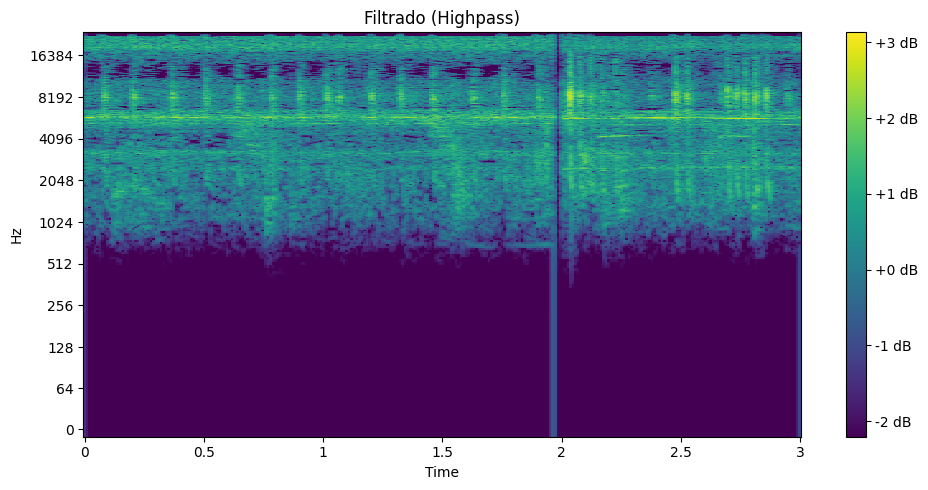

In [52]:
plt.figure(figsize=(10, 5))

librosa.display.specshow(D, sr=48000, x_axis='time', y_axis='log', cmap='viridis')
plt.title("Filtrado (Highpass)")
plt.colorbar(format='%+2.0f dB')

plt.tight_layout()
plt.show()

In [40]:
import numpy as np
t = np.load('Aves\\NPZ\\Amazilia_tzacatl_iNat1099629_chunk0.npz')

In [41]:
D = t['spec']

In [53]:
D.shape

(1025, 282)

In [54]:
import numpy as np
from birdnetlib.analyzer import Analyzer
from birdnetlib import RecordingBuffer
from datetime import datetime

# # Paso 1: Crear un array sintético tipo float32
# sample_rate = 32000  # BirdNET exige 48kHz
# duration = 3  # segundos
# audio_array = np.random.uniform(low=-1.0, high=1.0, size=sample_rate * duration).astype(np.float32)

# Paso 2: Inicializar el analizador
analyzer = Analyzer()  # Usa BirdNET-Lite sin metadatos

# Paso 3: Crear el buffer con metadatos
recording = RecordingBuffer(
    analyzer,
    D,
    rate= 48000
    # lat=10.3016,
    # lon=-74.199,
    # date=datetime(year=2025, month=7, day=29),
    # min_conf=0.3
)

# Paso 4: Analizar el audio
recording.analyze()

# Paso 5: Ver resultados
for det in recording.detections:
    print(f"{det['common_name']} - {det['confidence']:.2f}")


Labels loaded.
load model True
Model loaded.
Labels loaded.
load_species_list_model


ValueError: vector too long

In [57]:
from birdnetlib.analyzer import Analyzer
from birdnetlib import RecordingBuffer

analyzer = Analyzer()

recording = RecordingBuffer(
    analyzer,
    D,              # tu matriz de espectrograma
    rate=48000
)

recording.analyze()
for det in recording.detections:
    print(f"{det['common_name']} – {det['confidence']:.2f}")


Labels loaded.
load model True
Model loaded.
Labels loaded.
load_species_list_model


ValueError: vector too long